<a href="https://colab.research.google.com/github/luizkrawiec/estatistics/blob/main/correla%C3%A7%C3%A3o_e_regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import  numpy as np
import  pandas as pd
import  matplotlib.pyplot as plt
import  seaborn as sns
import  scipy.stats as stats
import plotly.express as px
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

In [2]:
enem_sp = pd.read_csv('/content/enem_2019_tratado.csv', sep=',', encoding='iso-8859-1')

In [3]:
colegiox = enem_sp.loc[enem_sp.CO_ESCOLA == 35017632.0]

In [4]:
colegiox.shape

(41, 28)

In [5]:
#lista com nota final
nota_final = ['NOTA_CN', 'NOTA_CH', 'NOTA_MT', 'NOTA_LC', 'NOTA_REDACAO']

In [6]:
colegiox['nota_final'] = (colegiox[nota_final].mean(axis=1))

<ipython-input-6-97f0868ea4f7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  colegiox['nota_final'] = (colegiox[nota_final].mean(axis=1))


In [7]:
colegiox.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET,nota_final
37,"1,90E+11",Águas de Lindóia,18,M,1,branca,1,2,pública,35017632.0,...,Inglês,1.0,120.0,40.0,40.0,120.0,20.0,340.0,Sim,385.58
44,"1,90E+11",Águas de Lindóia,17,F,1,parda,1,2,pública,35017632.0,...,Inglês,1.0,140.0,120.0,140.0,160.0,160.0,720.0,Não,548.42
52,"1,90E+11",Águas de Lindóia,17,F,1,branca,1,2,pública,35017632.0,...,Espanhol,1.0,120.0,120.0,120.0,120.0,80.0,560.0,Não,399.60
65,"1,90E+11",Águas de Lindóia,17,M,1,parda,1,2,pública,35017632.0,...,Inglês,1.0,120.0,120.0,120.0,120.0,40.0,520.0,Sim,446.16
79,"1,90E+11",Águas de Lindóia,18,F,1,branca,1,2,pública,35017632.0,...,Espanhol,1.0,120.0,120.0,120.0,140.0,140.0,640.0,Sim,433.62


In [8]:
notas_colegiox = colegiox[[ 'NOTA_CN', 'NOTA_CH', 'NOTA_MT', 'NOTA_LC', 'NOTA_REDACAO', 'nota_final']]

In [9]:
notas_colegiox

,NOTA_CN,NOTA_CH,NOTA_MT,NOTA_LC,NOTA_REDACAO,nota_final
37,46.3,447.2,537.1,557.3,340.0,385.58
44,505.9,534.5,451.9,529.8,720.0,548.42
52,449.4,436.4,506.4,45.8,560.0,399.60
65,468.6,606.1,59.5,576.6,520.0,446.16
79,414.3,553.7,510.6,49.5,640.0,433.62
84,397.8,458.5,420.6,473.5,360.0,422.08
85,469.1,528.7,508.2,488.4,680.0,534.88
91,436.3,528.8,537.9,530.7,560.0,518.74
17070,464.8,501.5,500.3,566.3,600.0,526.58
17072,465.8,488.4,42.4,46.8,520.0,312.68


# **Grafico de Correlação**

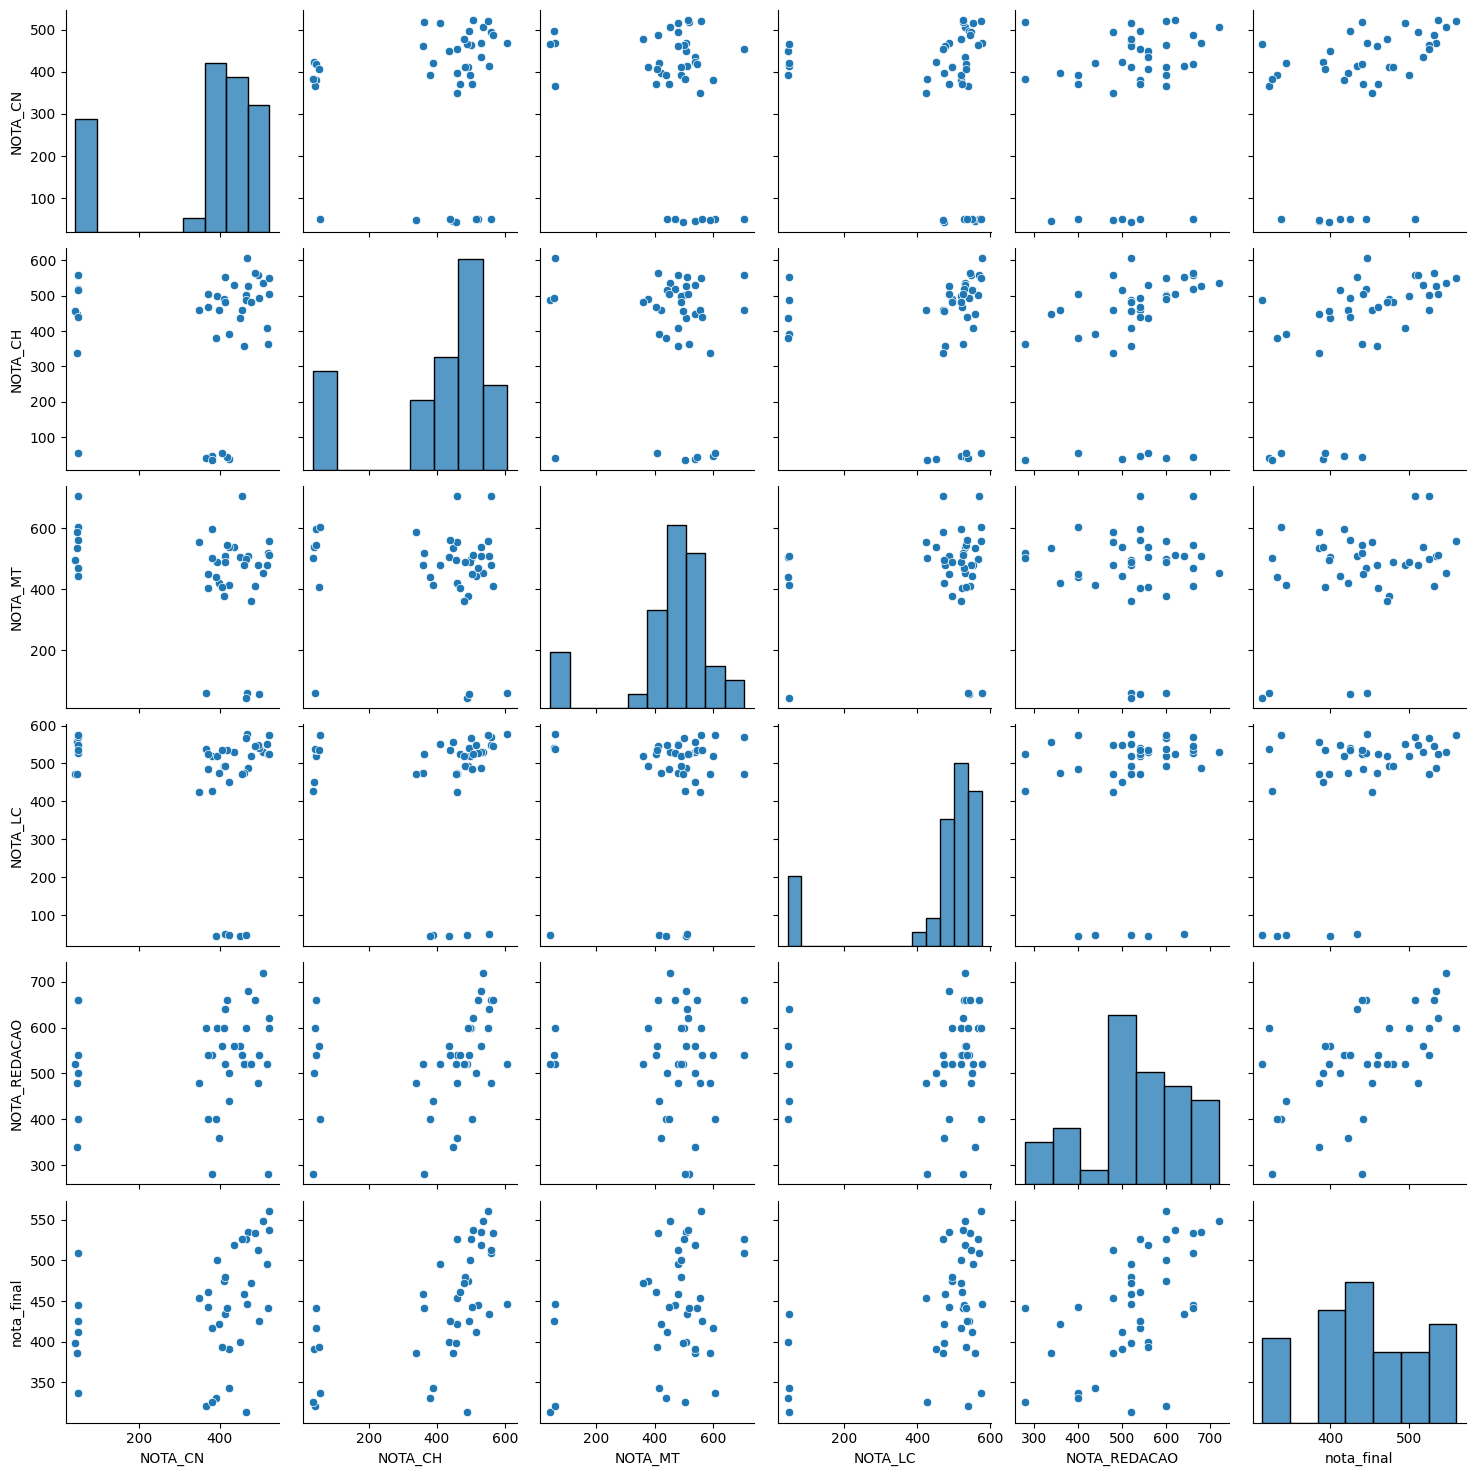

In [10]:
sns.pairplot(notas_colegiox)

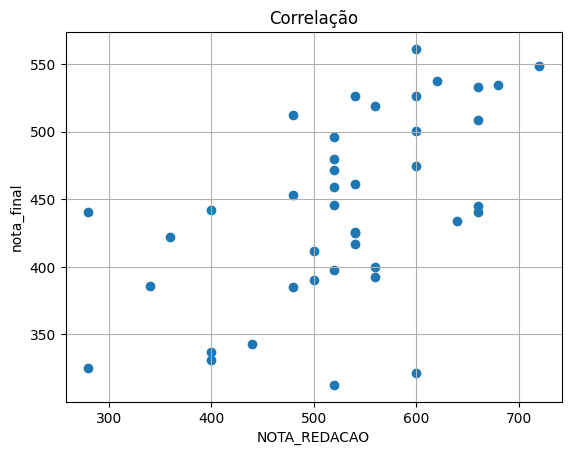

In [11]:
plt.scatter(notas_colegiox.NOTA_REDACAO, notas_colegiox.nota_final)
plt.title('Correlação')
plt.xlabel('NOTA_REDACAO')
plt.ylabel('nota_final')
plt.grid(True)
plt.show()

In [12]:
correlacoes = notas_colegiox.corr(method='pearson')

In [13]:
correlacoes

,NOTA_CN,NOTA_CH,NOTA_MT,NOTA_LC,NOTA_REDACAO,nota_final
NOTA_CN,1.000000,0.083520,-0.299411,-0.158243,0.132366,0.352986
NOTA_CH,0.083520,1.000000,-0.078817,-0.040875,0.264781,0.579168
NOTA_MT,-0.299411,-0.078817,1.000000,0.137463,-0.024316,0.322042
NOTA_LC,-0.158243,-0.040875,0.137463,1.000000,0.125635,0.472561
NOTA_REDACAO,0.132366,0.264781,-0.024316,0.125635,1.000000,0.551220
nota_final,0.352986,0.579168,0.322042,0.472561,0.551220,1.000000


<Axes: >

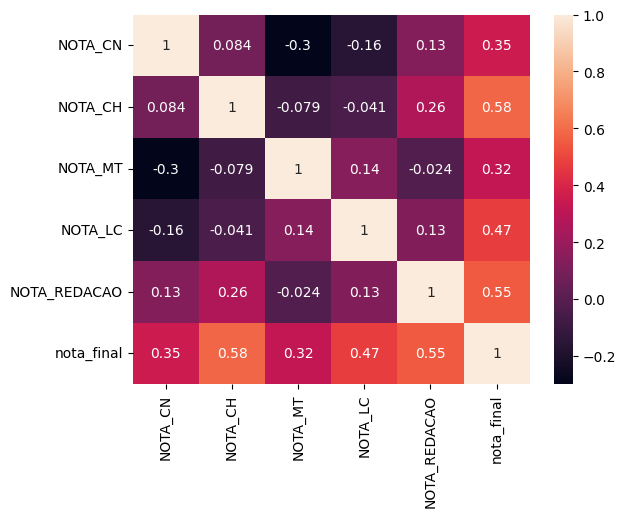

In [14]:
plt.figure()
sns.heatmap(correlacoes, annot=True)

# **Análise da Normalidade**

## **Teste Shapiro-Wilk**

Ho = distribuição normal: p>0.005

Ha = distribuição != normal: p <= 0.005

In [15]:
#Nota redação
stats.shapiro(notas_colegiox.NOTA_REDACAO)

ShapiroResult(statistic=0.9529756903648376, pvalue=0.08905091136693954)

In [16]:
# Nota final
stats.shapiro(notas_colegiox.nota_final)

ShapiroResult(statistic=0.9638933539390564, pvalue=0.21481332182884216)

In [17]:
# Nota Matematica
stats.shapiro(notas_colegiox.NOTA_MT)

ShapiroResult(statistic=0.798567533493042, pvalue=5.104646334075369e-06)

In [18]:
# Nota ciencias da natureza
stats.shapiro(notas_colegiox.NOTA_CN)

ShapiroResult(statistic=0.7349029779434204, pvalue=2.995314787312964e-07)

In [19]:
#Notas linguagem e códigos
stats.shapiro(notas_colegiox.NOTA_LC)

ShapiroResult(statistic=0.5986173152923584, pvalue=2.23514540209635e-09)

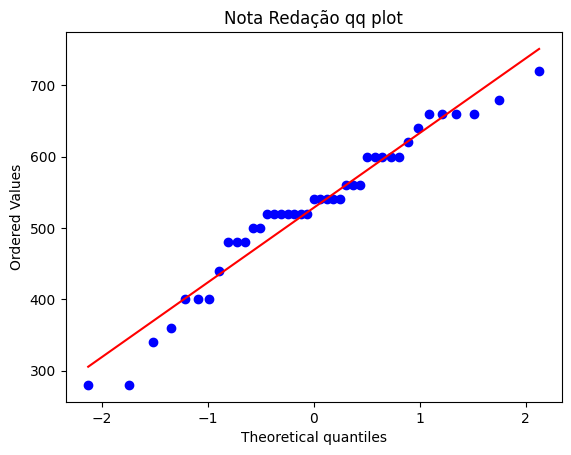

In [20]:
stats.probplot(notas_colegiox.NOTA_REDACAO, dist='norm', plot=plt)
plt.title('Nota Redação qq plot')
plt.show()

In [21]:
grafico = px.box(notas_colegiox, y='NOTA_REDACAO')
grafico.show()

In [22]:
grafico = px.box(notas_colegiox, y='NOTA_MT')
grafico.show()

In [23]:
grafico = px.box(notas_colegiox, y='NOTA_CN')
grafico.show()

In [24]:
grafico = px.box(notas_colegiox, y='NOTA_LC')
grafico.show()

In [25]:
grafico = px.box(notas_colegiox, y='nota_final')
grafico.show()

# **Regressão Linear**

## **1. Regressão Linear com Statsmodels**

In [30]:
regressao = smf.ols('nota_final ~ NOTA_REDACAO', data=notas_colegiox).fit()
print(regressao.summary())

                            OLS Regression Results                            
Dep. Variable:             nota_final   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     17.02
Date:                Fri, 05 Jul 2024   Prob (F-statistic):           0.000188
Time:                        17:41:37   Log-Likelihood:                -223.52
No. Observations:                  41   AIC:                             451.0
Df Residuals:                      39   BIC:                             454.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      251.6789     47.319      5.319   

In [31]:
coefs = pd.DataFrame(regressao.params)
coefs.columns = ['Coeficientes']
print(coefs)

              Coeficientes
Intercept       251.678855
NOTA_REDACAO      0.362749


Equação:

Nota Final = 251,678855 + 0,362749.Nota Redação


In [32]:
notas_colegiox.head()

,NOTA_CN,NOTA_CH,NOTA_MT,NOTA_LC,NOTA_REDACAO,nota_final
37,46.3,447.2,537.1,557.3,340.0,385.58
44,505.9,534.5,451.9,529.8,720.0,548.42
52,449.4,436.4,506.4,45.8,560.0,399.60
65,468.6,606.1,59.5,576.6,520.0,446.16
79,414.3,553.7,510.6,49.5,640.0,433.62


In [33]:
regressao.predict()

array([375.01357169, 512.85825473, 454.81838819, 440.30842155,
       483.83832146, 382.268555  , 498.3482881 , 454.81838819,
       469.32835482, 440.30842155, 447.56340487, 433.05343823,
       491.09330478, 353.24862173, 440.30842155, 411.28848828,
       425.79845491, 440.30842155, 425.79845491, 447.56340487,
       491.09330478, 491.09330478, 447.56340487, 491.09330478,
       440.30842155, 469.32835482, 469.32835482, 396.77852164,
       447.56340487, 425.79845491, 396.77852164, 469.32835482,
       454.81838819, 433.05343823, 440.30842155, 353.24862173,
       469.32835482, 447.56340487, 440.30842155, 396.77852164,
       476.58333814])

In [34]:
residuos = regressao.resid

In [35]:
residuos

37         10.566428
44         35.561745
52        -55.218388
65          5.851578
79        -50.218321
84         39.811445
85         36.531712
91         63.921612
17070      57.251645
17072    -127.628422
17078     -22.083405
17110     -42.653438
108151     17.606695
108155     87.571378
108180     55.451578
138498    -68.448488
182510     86.501545
182519     18.771578
182528     27.621545
182546    -30.503405
182581    -45.833305
182613    -50.333305
182614     78.516595
182615     42.066695
182637    -42.508422
182683     31.031645
182697   -148.128355
230978    -59.558522
287389     13.896595
287716    -40.338455
347945    -65.858522
365950      5.551645
365951    -61.998388
365980    -21.493438
365984     39.151578
365986    -28.028622
378313     91.931645
445647    -22.163405
445741     31.491578
445790     45.381478
445809     60.956662
dtype: float64

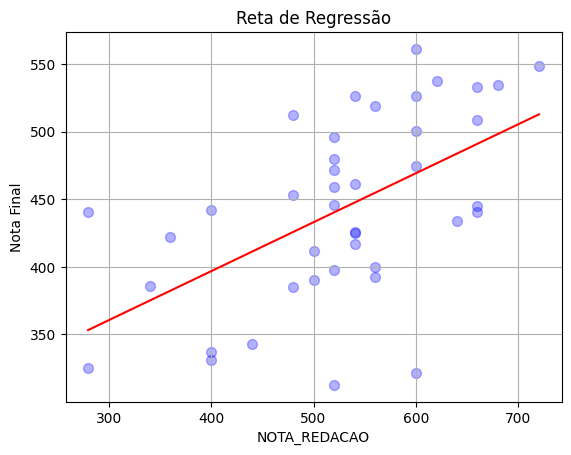

In [38]:
plt.scatter(y = notas_colegiox.nota_final, x=notas_colegiox.NOTA_REDACAO, color='blue', s=50, alpha=0.3)
x_plot = np.linspace(min(notas_colegiox.NOTA_REDACAO), max(notas_colegiox.NOTA_REDACAO), len(notas_colegiox.NOTA_REDACAO))
#x_plot = np.linspace(0,1000)
plt.plot(x_plot, x_plot*regressao.params[1] + regressao.params[0],color='r')
plt.title('Reta de Regressão')
plt.xlabel('NOTA_REDACAO')
plt.ylabel('Nota Final')
plt.grid(True)
plt.show()

# **Teste de normalidade dos resíduos**

In [39]:
# Residuos da nota redação
stats.shapiro(residuos)

ShapiroResult(statistic=0.9587119221687317, pvalue=0.1417592167854309)

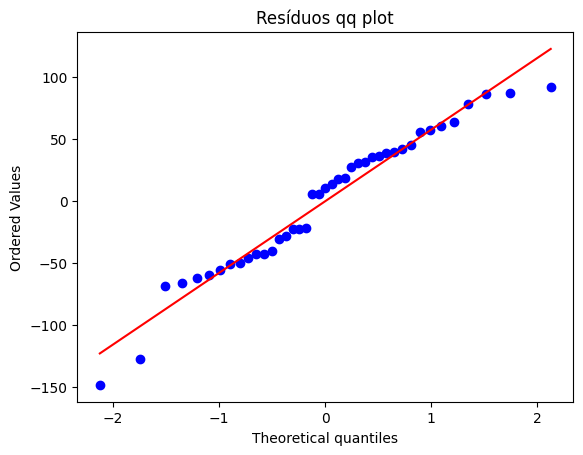

In [40]:
stats.probplot(residuos, dist='norm', plot=plt)
plt.title('Resíduos qq plot')
plt.show()

## **Análise da homocedasticidade dos resíduos**

(resíduos com variação constante)

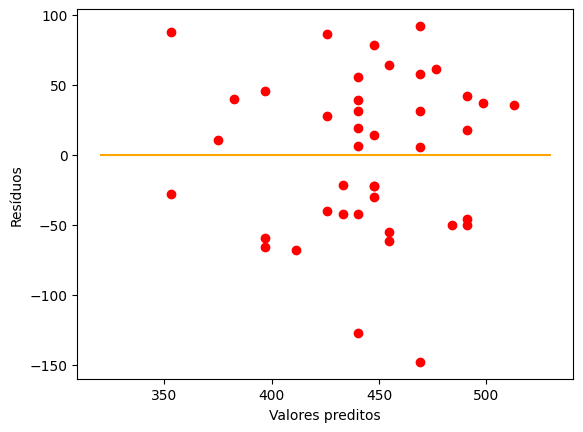

In [43]:
plt.scatter (y=residuos, x=regressao.predict(),color='red')
plt.hlines(y=0, xmin=320, xmax=530, color='orange')
plt.ylabel('Resíduos')
plt.xlabel('Valores preditos')
plt.show()